# Classification — Phân loại AQI 6 mức | Hà Nội 2022–2025
> **Pipeline:** Random Forest → XGBoost  
> **Xử lý mất cân bằng:** `class_weight` / `scale_pos_weight`  
> **Đánh giá:** F1-macro · ROC-AUC ·   
> **Output:** `xgboost_best_model.json` 

## 0. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import joblib, json

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({'figure.dpi': 130})

CAT_ORDER = ['Good', 'Moderate', 'Unhealthy for sensitive groups',
             'Unhealthy', 'Very Unhealthy', 'Hazardous']

# ── Kết nối MySQL ─────────────────────────────────────────────────────────
load_dotenv()

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
df = pd.read_sql("SELECT * FROM aqi_data", con=engine)
df.columns = df.columns.str.strip().str.lower()
print(f"✅ {df.shape[0]:,} hàng × {df.shape[1]} cột")

# ── Features & Labels ─────────────────────────────────────────────────────
FEAT_COLS = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
             'clouds', 'precipitation', 'pressure', 'relative_humidity',
             'temperature', 'uv_index', 'wind_speed',
             'hour', 'month', 'season', 'is_weekend', 'is_rush_hour', 'day_of_week']

X  = df[FEAT_COLS].fillna(df[FEAT_COLS].median())
le = LabelEncoder()
le.fit(CAT_ORDER)
y  = le.transform(df['aqi_category'])

print(f"Features: {len(FEAT_COLS)} cột")
print(f"Classes:  {list(le.classes_)}")

ValueError: invalid literal for int() with base 10: 'None'

## 2. Chia tập Train/Test theo thời gian & Class Weight
**Chiến lược chia dữ liệu theo thời gian** (không random) — phản ánh đúng thực tế dự báo:
- **Train:** 2022 – 2024 (~25,996 mẫu)  
- **Test:** 2025 (~4,345 mẫu)

Dùng **`class_weight='balanced'`** (RF) và **`sample_weight`** (XGBoost) để tự động penalize class đa số.

In [ ]:
# ── Chia tập theo thời gian ────────────────────────────────────────────────
mask_train = df['year'].isin([2022, 2023, 2024])
mask_test  = df['year'] == 2025

X_train = X[mask_train]
X_test  = X[mask_test]
y_train = y[mask_train]
y_test  = y[mask_test]

print(f"Train (2022–2024): {len(X_train):,} mẫu")
print(f"Test  (2025)     : {len(X_test):,} mẫu")
print()

# ── Tính class weights ─────────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(le.classes_)),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# sample_weight cho XGBoost (gán weight cho từng mẫu train)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# y_bin dùng cho ROC-AUC
y_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

print("Class weights (balanced):")
for idx, w in class_weight_dict.items():
    bar = '█' * int(w * 3)
    print(f"  [{idx}] {le.classes_[idx]:<38}: {w:.3f}  {bar}")
print()
print("Phân bố class trong tập Test (2025):")
for cls, cnt in zip(le.classes_, np.bincount(y_test)):
    bar = '█' * int(cnt / len(y_test) * 30)
    print(f"  {cls:<38}: {cnt:>5,} ({cnt/len(y_test)*100:5.1f}%)  {bar}")

Train (2022–2024): 25,992 mẫu
Test  (2025)     : 4,344 mẫu

Class weights (balanced):
  [0] Good                                  : 4.328  ████████████
  [1] Hazardous                             : 240.667  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  [2] Moderate                              : 0.408  █
  [3] Unhealthy

## 3. Random Forest
Model baseline mạnh — không cần scale, robust với outliers.

In [ ]:
print("Training Random Forest (n_estimators=200, class_weight='balanced')...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # <-- thay SMOTE
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
auc_rf = roc_auc_score(y_bin, y_prob_rf, average='macro', multi_class='ovr')

print(f"\n✅ Random Forest:")
print(f"   F1-macro  = {f1_rf:.4f}")
print(f"   ROC-AUC   = {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, digits=4))

Training Random Forest (n_estimators=200, class_weight='balanced')...

✅ Random Forest:
   F1-macro  = 0.8224
   ROC-AUC   = 0.9993

                                precision    recall  f1-score   support

                          Good     0.9630    0.9630    0.9630        27
                     Hazardous     0.0000    0.0000    0.0000         1
                      Moderate     0.9925    0.9981    0.9953      1060
                     Unhealthy     0.9865    0.9942    0.9903      1026
Unhealthy for sensitive groups     0.9986    0.9906    0.9946      1483
                Very Unhealthy     0.9920    0.9906    0.9913       747

                      accuracy                         0.9929      4344
                     macro avg     0.8221    0.8227    0.8224      4344
                  weighted avg     0.9927    0.9929    0.9928      4344



## 4. XGBoost
Gradient boosting — thường vượt RF trên tabular data có class imbalance.

In [ ]:
print("Training XGBoost (n_estimators=300, sample_weight=balanced)...")
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
# XGBoost không có class_weight trực tiếp → dùng sample_weight
xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')
auc_xgb = roc_auc_score(y_bin, y_prob_xgb, average='macro', multi_class='ovr')

print(f"\n✅ XGBoost:")
print(f"   F1-macro  = {f1_xgb:.4f}")
print(f"   ROC-AUC   = {auc_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, digits=4))

Training XGBoost (n_estimators=300, sample_weight=balanced)...

✅ XGBoost:
   F1-macro  = 0.8166
   ROC-AUC   = 0.9990

                                precision    recall  f1-score   support

                          Good     0.9000    1.0000    0.9474        27
                     Hazardous     0.0000    0.0000    0.0000         1
                      Moderate     0.9831    0.9868    0.9849      1060
                     Unhealthy     0.9874    0.9932    0.9903      1026
Unhealthy for sensitive groups     0.9919    0.9858    0.9888      1483
                Very Unhealthy     0.9906    0.9853    0.9879       747

                      accuracy                         0.9876      4344
                     macro avg     0.8088    0.8252    0.8166      4344
                  weighted avg     0.9876    0.9876    0.9876      4344



## 5. Lưu best model XGBoost (cho Linh Linh dùng SHAP)

In [ ]:

import json, pickle

xgb.save_model('xgboost_best_model.json')

meta = {
    'label_encoder_classes': le.classes_.tolist(),
    'features': FEAT_COLS,
    'f1_macro_xgb': float(f1_xgb),
    'f1_macro_rf':  float(f1_rf),
}
with open('xgboost_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print()


## 6. Bảng so sánh Random Forest vs XGBoost

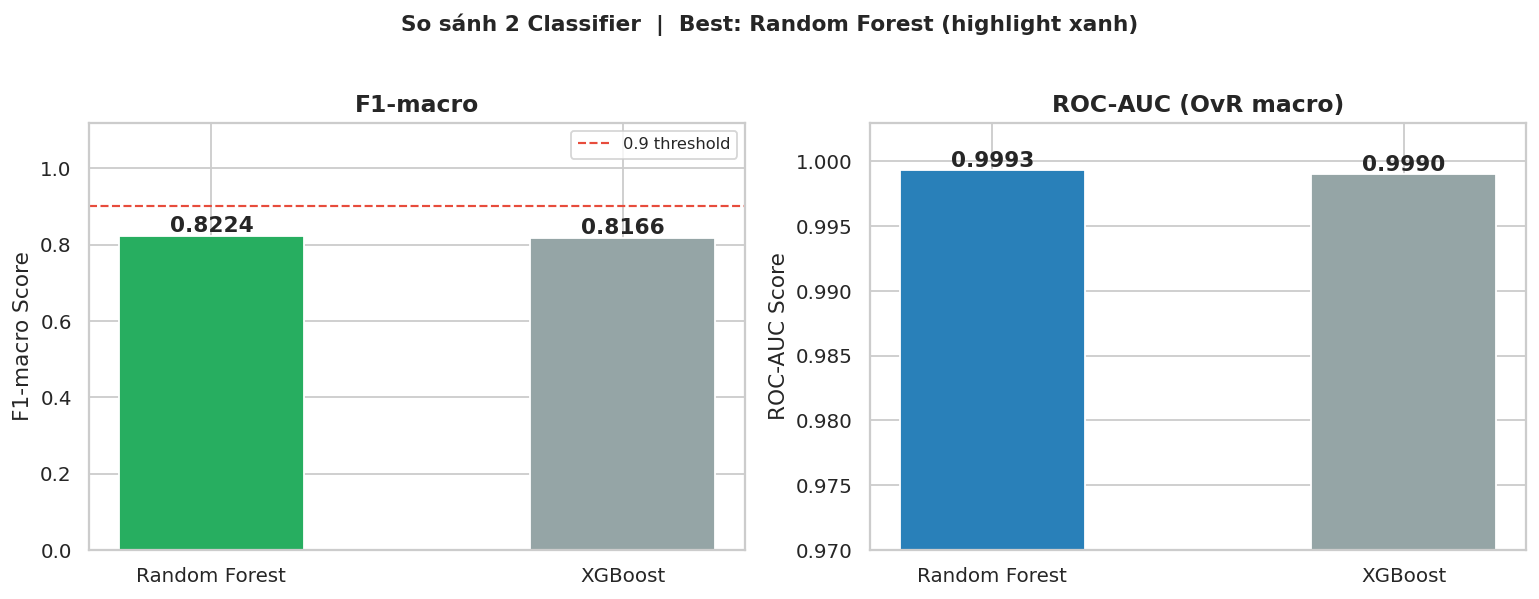

Model                  F1-macro    ROC-AUC
------------------------------------------
Random Forest            0.8224     0.9993 ← BEST
XGBoost                  0.8166     0.9990


In [ ]:
models     = ['Random Forest', 'XGBoost']
f1s        = [f1_rf,  f1_xgb]
aucs       = [auc_rf, auc_xgb]
best_idx   = int(np.argmax(f1s))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bar_colors_f1  = ['#95a5a6', '#95a5a6']
bar_colors_auc = ['#95a5a6', '#95a5a6']
bar_colors_f1[best_idx]  = '#27ae60'
bar_colors_auc[best_idx] = '#2980b9'

# F1-macro
b1 = axes[0].bar(models, f1s, color=bar_colors_f1, edgecolor='white', width=0.45)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('F1-macro Score', fontsize=12)
axes[0].set_title('F1-macro', fontsize=13, fontweight='bold')
axes[0].axhline(0.9, ls='--', color='#e74c3c', lw=1.2, label='0.9 threshold')
axes[0].legend(fontsize=9)
for bar, v in zip(b1, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# ROC-AUC
b2 = axes[1].bar(models, aucs, color=bar_colors_auc, edgecolor='white', width=0.45)
axes[1].set_ylim(0.97, 1.003)
axes[1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1].set_title('ROC-AUC (OvR macro)', fontsize=13, fontweight='bold')
for bar, v in zip(b2, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

fig.suptitle(f'So sánh 2 Classifier  |  Best: {models[best_idx]} (highlight xanh)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Model':<20} {'F1-macro':>10} {'ROC-AUC':>10}")
print("-"*42)
for m, f1, auc in zip(models, f1s, aucs):
    flag = " ← BEST" if f1 == max(f1s) else ""
    print(f"{m:<20} {f1:>10.4f} {auc:>10.4f}{flag}")

## 7. F1-score từng class — RF vs XGBoost

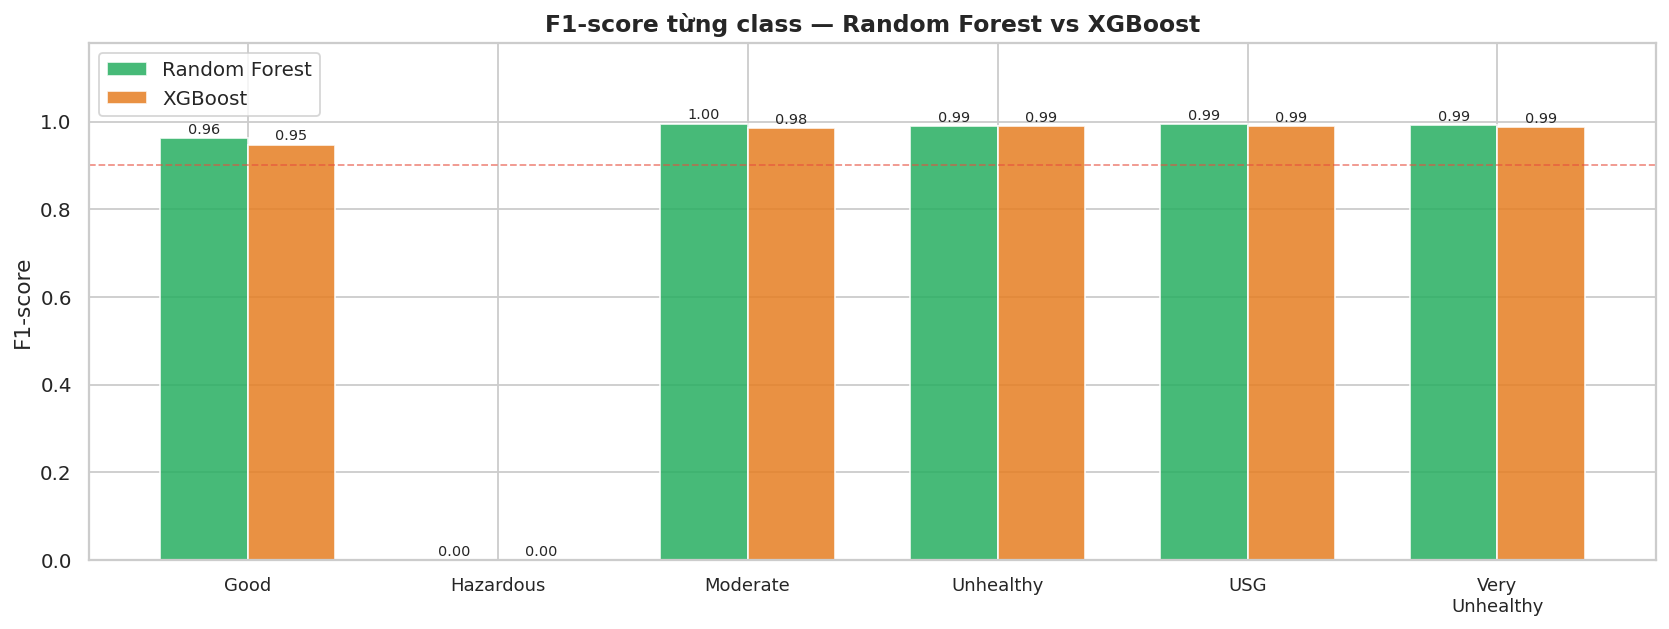

In [ ]:
short_labels = ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'USG', 'Very\nUnhealthy']
x = np.arange(len(le.classes_))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
for i, (mname, pred) in enumerate([('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    report   = classification_report(y_test, pred, output_dict=True, zero_division=0)
    f1_per   = [report[str(k)]['f1-score'] for k in range(len(le.classes_))]
    clr      = ['#27ae60', '#e67e22'][i]
    bars     = ax.bar(x + i*w, f1_per, w, label=mname, color=clr,
                      alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, f1_per):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + w/2)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('F1-score từng class — Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.axhline(0.9, ls='--', color='#e74c3c', lw=1, alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix trực quan từng class

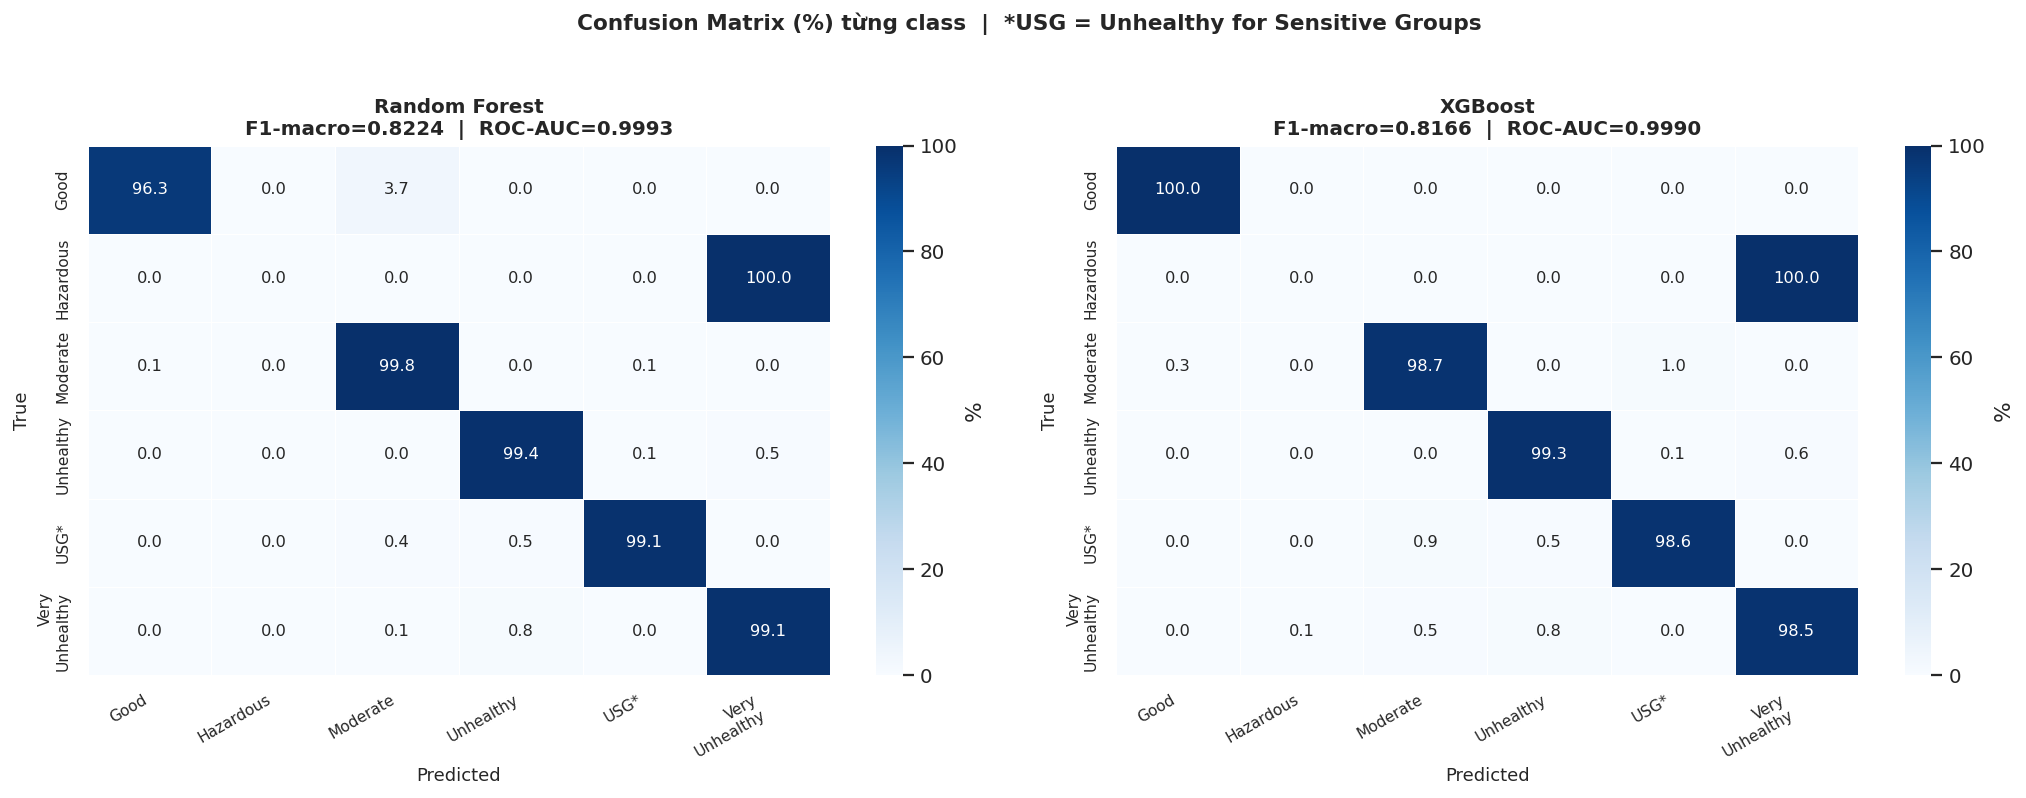

In [ ]:
cm_labels = ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'USG*', 'Very\nUnhealthy']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (mname, pred, f1, auc) in zip(axes, [
    ('Random Forest', y_pred_rf,  f1_rf,  auc_rf),
    ('XGBoost',       y_pred_xgb, f1_xgb, auc_xgb),
]):
    cm     = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=cm_labels, yticklabels=cm_labels,
                linewidths=0.5, cbar_kws={'label': '%'}, ax=ax,
                annot_kws={'size': 9})
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=8.5, rotation=30, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8.5)
    ax.set_title(f'{mname}\nF1-macro={f1:.4f}  |  ROC-AUC={auc:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrix (%) từng class  |  *USG = Unhealthy for Sensitive Groups',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance — XGBoost

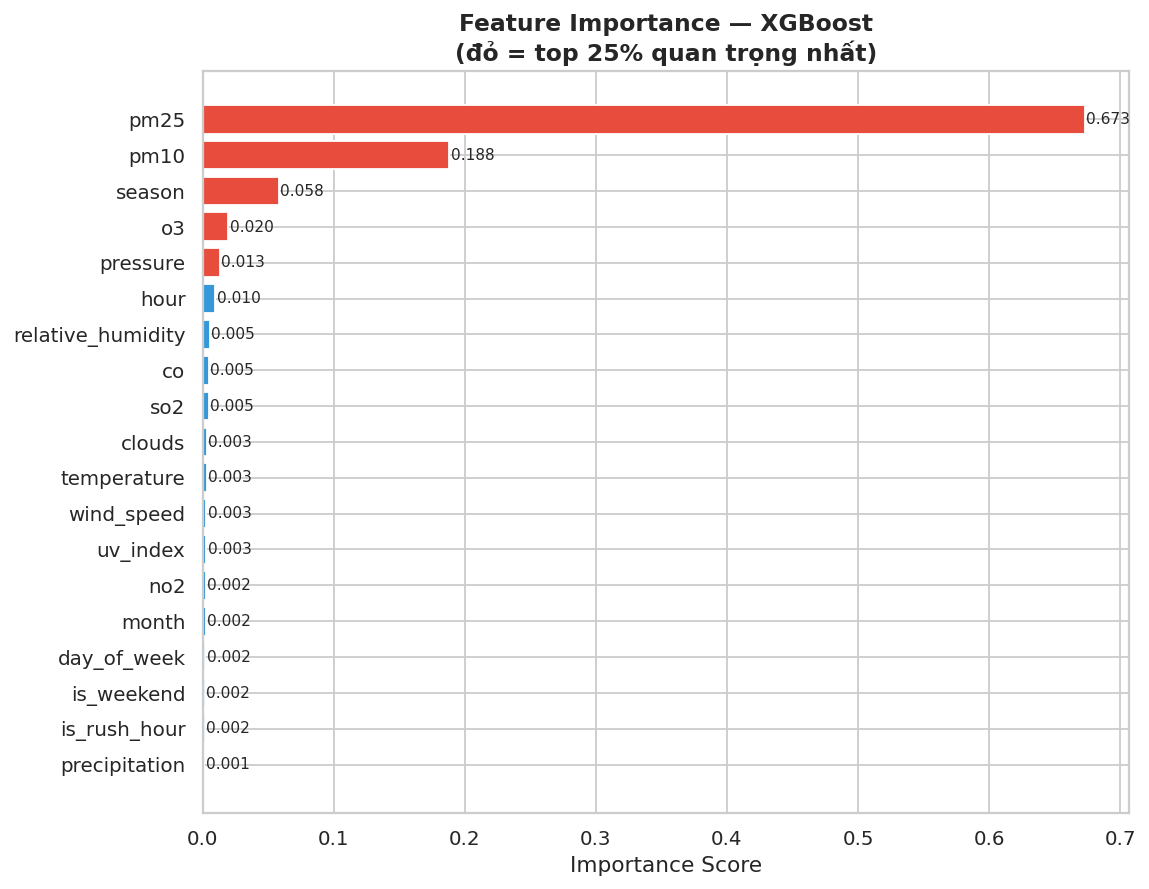

Top 5 features quan trọng nhất (XGBoost):
  pm25                  : 0.6732
  pm10                  : 0.1883
  season                : 0.0581
  o3                    : 0.0196
  pressure              : 0.0132


In [ ]:
importances = pd.Series(xgb.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if v >= importances.quantile(0.75) else '#3498db' for v in importances]
bars   = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance — XGBoost\n(đỏ = top 25% quan trọng nhất)',
             fontsize=13, fontweight='bold')

for bar, v in zip(bars, importances.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

print("Top 5 features quan trọng nhất (XGBoost):")
for feat, val in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22}: {val:.4f}")

## 10. Tổng kết kết quả

In [ ]:
print("=" * 60)
print("  KẾT QUẢ CLASSIFICATION — HÀ NỘI AQI 2022–2025")
print("=" * 60)
print(f"  {'Model':<20} {'F1-macro':>10} {'ROC-AUC':>10}")
print("  " + "-"*42)
for m, f1, auc in zip(models, f1s, aucs):
    flag = "  ← BEST" if f1 == max(f1s) else ""
    print(f"  {m:<20} {f1:>10.4f} {auc:>10.4f}{flag}")
print()
print(f"  Features:    {len(FEAT_COLS)} features ({', '.join(FEAT_COLS[:4])}...)")


  KẾT QUẢ CLASSIFICATION — HÀ NỘI AQI 2022–2025
  Model                  F1-macro    ROC-AUC
  ------------------------------------------
  Random Forest            0.8224     0.9993  ← BEST
  XGBoost                  0.8166     0.9990

  Features:    19 features (co, no2, o3, pm10...)
